# Tobacco Use and Mortality (2004–2015)
-------
### Tools Used:
- Jupyter Notebook
- Python Libraries: Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

--------
### Technologies:
- EDA
- Machine Learning

---------

# PART 1: Smoking Trends and Mortality Risk 
(Exploratory + Regression Focus)

## Objective: Analyze smoking prevalence and its relation to mortality rates over time.
Predict mortality counts using regression models.

----
#### Approach & Summary:
- Load and clean dataset:
  -  Handle missing values.
- Perform EDA:
  - Groupby age, gender, smoking type.
  - Visuals: Heatmap correlations, Pie Chart of smoking frequency, Tobacco Price Index, Smoking prevalence trends.
- ML Algorithms:
  - Random Forest Regression
  - XGBoost Regression
  - Decision Tree Regression
- Visuals:
  - Regression metrics (MSE,MAE)
  - Actual vs Predicted
-------

## 1) Load Dataset

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set_palette("pastel")
plt.style.use("seaborn-v0_8-pastel")
pastel_colors = ["#aec6cf", "#f9e79f", "#77dd77", "#ffb347", "#cbaacb", "#ff6961"]

# Load cleaned dataset
df = pd.read_csv("tobacco_mortality.csv")
df.head()

,Year,All Pharmacotherapy Prescriptions,Nicotine Replacement Therapy (NRT) Prescriptions,Bupropion (Zyban) Prescriptions,Varenicline (Champix) Prescriptions,Net Ingredient Cost of All Pharmacotherapies,Net Ingredient Cost of Nicotine Replacement Therapies (NRT),Net Ingredient Cost of Bupropion (Zyban),Net Ingredient Cost of Varenicline (Champix),Tobacco Price\nIndex,...,25-34,35-49,50-59,60 and Over,ICD10 Code_y,ICD10 Diagnosis_y,Diagnosis Type_y,Metric_y,Sex,Value_y
0,2006,2079.0,1938.0,119.0,22.0,44817.0,39743.0,4315.0,760.0,713.7,...,33.0,26.0,23.0,13.0,All codes,All admissions,All admissions,Number of admissions,Male,3959716
1,2006,2079.0,1938.0,119.0,22.0,44817.0,39743.0,4315.0,760.0,713.7,...,33.0,26.0,23.0,13.0,C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...,All diseases which can be caused by smoking,All diseases which can be caused by smoking,Number of admissions,Male,790240
2,2006,2079.0,1938.0,119.0,22.0,44817.0,39743.0,4315.0,760.0,713.7,...,33.0,26.0,23.0,13.0,C00-D48,All cancers,All cancers,Number of admissions,Male,636115
3,2006,2079.0,1938.0,119.0,22.0,44817.0,39743.0,4315.0,760.0,713.7,...,33.0,26.0,23.0,13.0,J00-J99,All respiratory diseases,All respiratory diseases,Number of admissions,Male,210662
4,2006,2079.0,1938.0,119.0,22.0,44817.0,39743.0,4315.0,760.0,713.7,...,33.0,26.0,23.0,13.0,I00-I99,All circulatory diseases,All circulatory diseases,Number of admissions,Male,486391


In [56]:
# Quick info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240408 entries, 0 to 240407
Data columns (total 37 columns):
 #   Column                                                       Non-Null Count   Dtype  
---  ------                                                       --------------   -----  
 0   Year                                                         240408 non-null  int64  
 1   All Pharmacotherapy Prescriptions                            240408 non-null  float64
 2   Nicotine Replacement Therapy (NRT) Prescriptions             240408 non-null  float64
 3   Bupropion (Zyban) Prescriptions                              240408 non-null  float64
 4   Varenicline (Champix) Prescriptions                          240408 non-null  float64
 5   Net Ingredient Cost of All Pharmacotherapies                 240408 non-null  float64
 6   Net Ingredient Cost of Nicotine Replacement Therapies (NRT)  240408 non-null  float64
 7   Net Ingredient Cost of Bupropion (Zyban)                     2404

-----
## 2. Exploratory Data Analysis 

### A) Groupby Age, Gender, Smoking Type
Question: How does smoking prevalence vary by age group and gender?

In [3]:
gp = df.groupby(['Year','Sex'])[["16-24","25-34","35-49","50-59","60 and Over"]].mean()
print(gp.head(10))

             16-24  25-34  35-49  50-59  60 and Over
Year Sex                                            
2006 Female   25.5   29.5   25.5   22.5         12.5
     Male     25.5   29.5   25.5   22.5         12.5
2007 Female   26.0   26.0   24.0   21.5         12.5
     Male     26.0   26.0   24.0   21.5         12.5
2008 Female   26.5   27.5   24.0   21.5         12.5
     Male     26.5   27.5   24.0   21.5         12.5
2009 Female   25.0   25.5   24.5   21.0         14.0
     Male     25.0   25.5   24.5   21.0         14.0
2010 Female   23.0   26.5   24.0   20.0         13.0
     Male     23.0   26.5   24.0   20.0         13.0


### B) Heatmap of Correlations
Question: Which tobacco-use and socioeconomic variables are most strongly correlated with mortality?

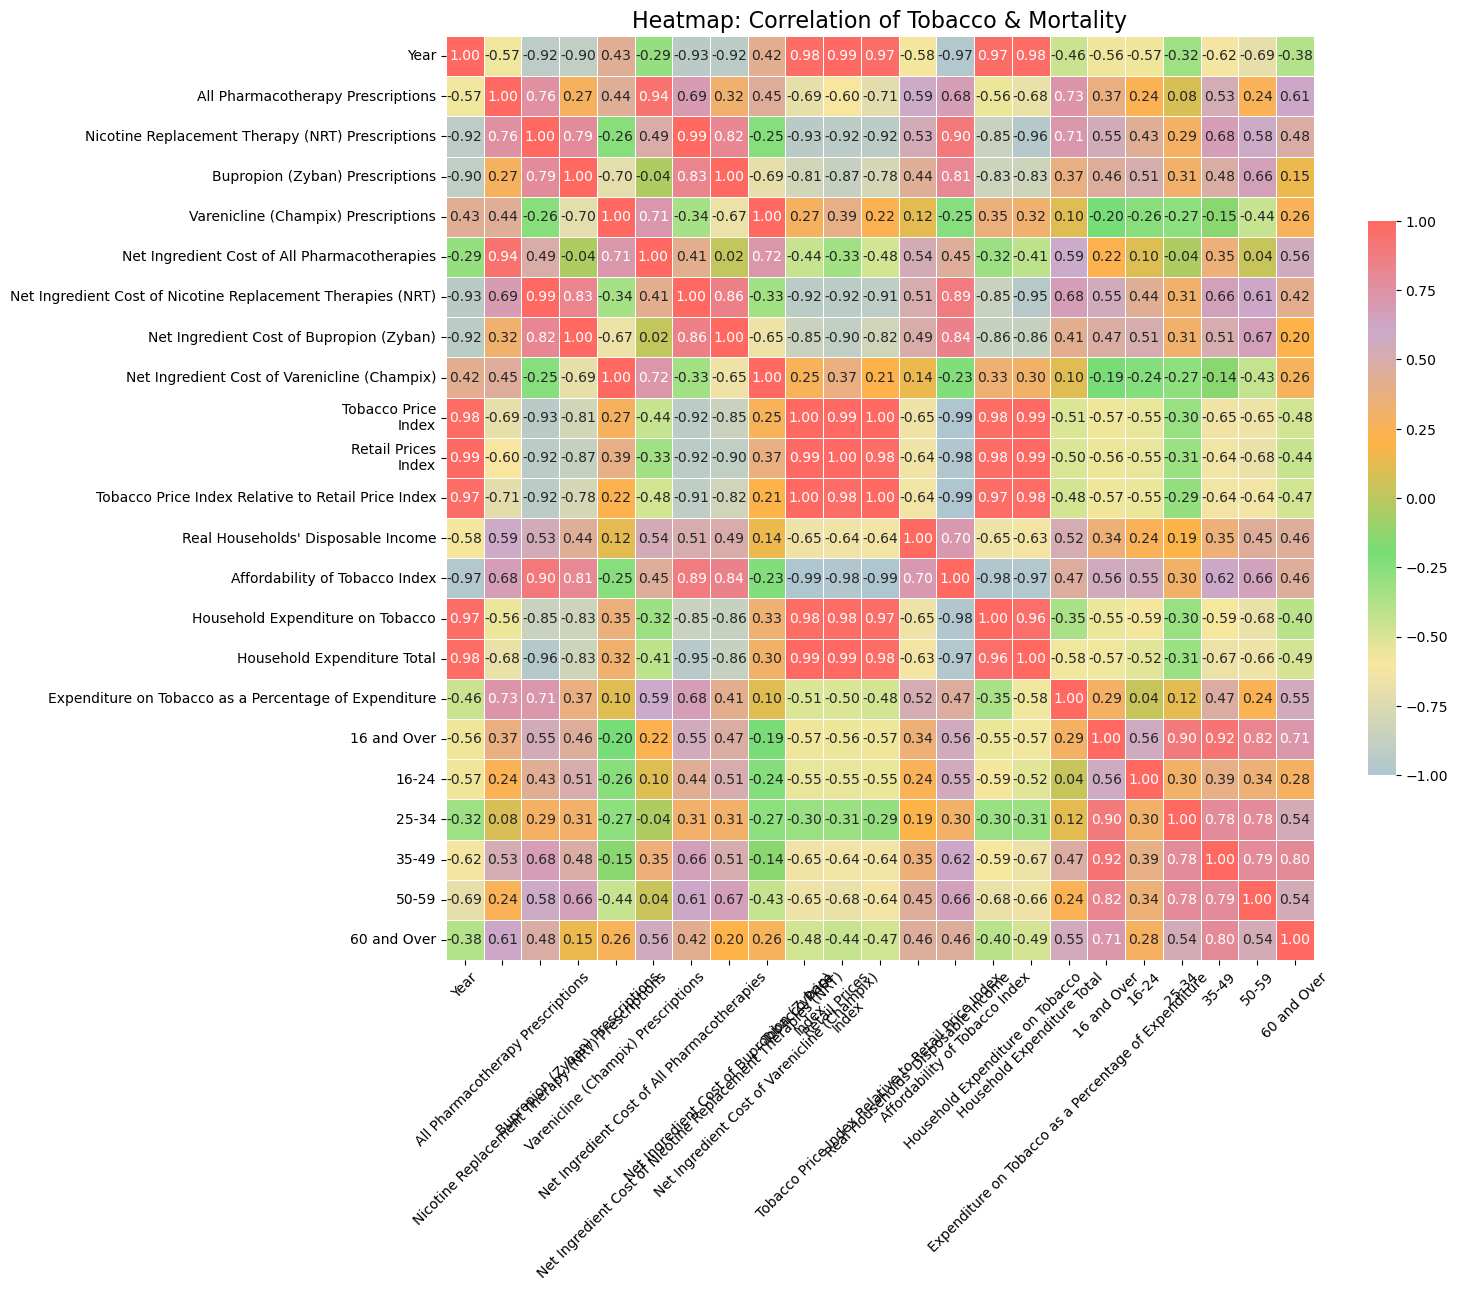

In [59]:
plt.figure(figsize=(14,12))
import matplotlib.colors as mcolors

# create a pastel colormap from the defined pastel_colors list
pastel_cmap = mcolors.LinearSegmentedColormap.from_list("pastel_cmap", pastel_colors)
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap=pastel_cmap, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0,linewidths=0.5, linecolor='white', cbar_kws={"shrink":0.6})
plt.title("Heatmap: Correlation of Tobacco & Mortality", fontsize=16)
plt.xticks(rotation=45)
plt.show()

### C) Pie Chart of Smoking Frequency
Question: What is the distribution of smoking prevalence across different age groups in the most recent year?

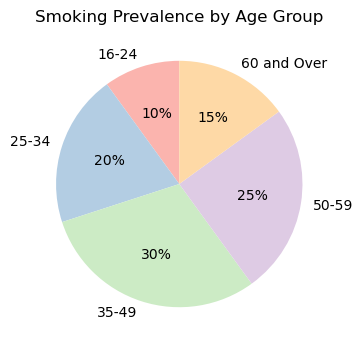

In [7]:
age_cols = ['16-24', '25-34', '35-49', '50-59', '60 and Over']

colors = plt.cm.Pastel1(range(len(age_cols)))
plt.figure(figsize=(8,4))
plt.pie(prevalence, labels=age_cols, autopct='%1.f%%', startangle=90, colors=colors)
plt.title('Smoking Prevalence by Age Group')
plt.show()

### D) Smoking Prevalence Trends.
Question: How have smoking rates changed over time across different age groups, and which age groups show the most significant trends or shifts in smoking prevalence?"

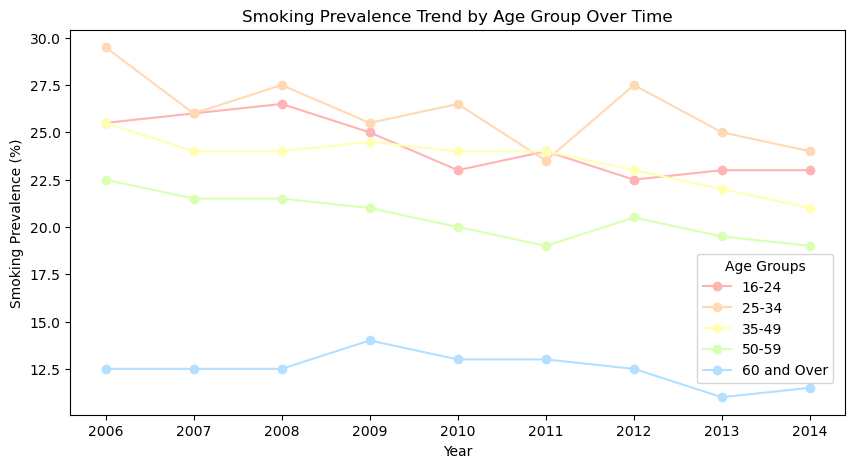

In [25]:
# Example data: Replace these arrays with your actual yearly data per age group
years = sorted(df['Year'].unique())

age_groups = ['16-24', '25-34', '35-49', '50-59', '60 and Over']

plt.figure(figsize=(10,5))

# Pastel colors (one for each age group)
pastel_colors = ['#ffb3b3', '#ffd9b3', '#ffffb3', '#d9ffb3', '#b3e0ff']

for age, color in zip(age_groups, pastel_colors):
    trend = df.groupby('Year')[age].mean()
    plt.plot(years, trend.loc[years], marker='o', color=color, label=age)

plt.legend(title='Age Groups', loc='center left', bbox_to_anchor=(0.8, 0.25))
plt.title("Smoking Prevalence Trend by Age Group Over Time")
plt.xlabel('Year')
plt.ylabel('Smoking Prevalence (%)')
plt.show()

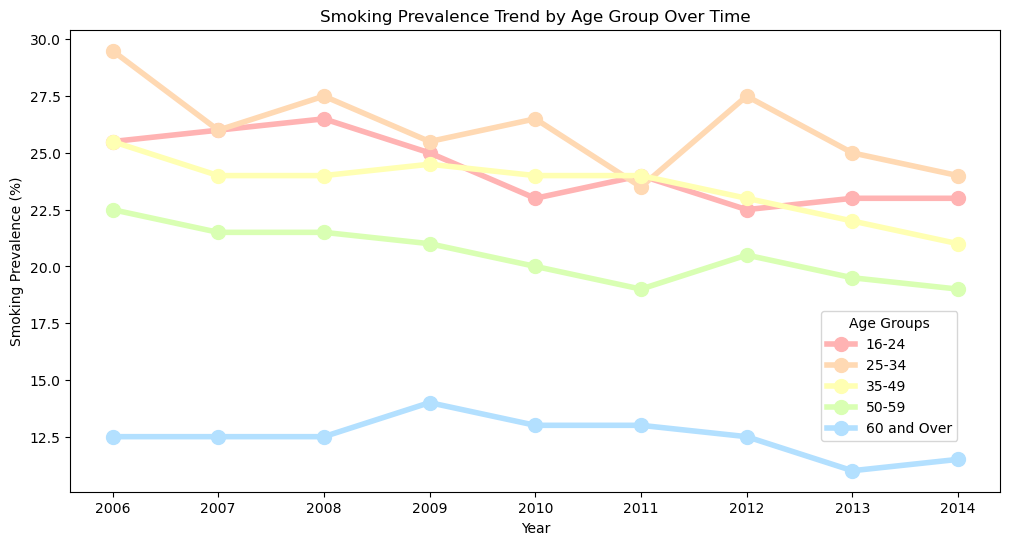

In [65]:
# Example data: Replace these arrays with your actual yearly data per age group
years = sorted(df['Year'].unique())

age_groups = ['16-24', '25-34', '35-49', '50-59', '60 and Over']

plt.figure(figsize=(12,6))

# Pastel colors (one for each age group)
pastel_colors = ['#ffb3b3', '#ffd9b3', '#ffffb3', '#d9ffb3', '#b3e0ff']

for age, color in zip(age_groups, pastel_colors):
    trend = df.groupby('Year')[age].mean()
    plt.plot(years, trend.loc[years], marker='o', color=color, label=age,markersize=10,  linewidth=4)

plt.legend(title='Age Groups', loc='center left', bbox_to_anchor=(0.8, 0.25))
plt.title("Smoking Prevalence Trend by Age Group Over Time")
plt.xlabel('Year')
plt.ylabel('Smoking Prevalence (%)')
plt.show()

### D) Tobacco Price Index
Question: How does the Tobacco Price Index Relative to the Retail Price Index relate to mortality counts over time?

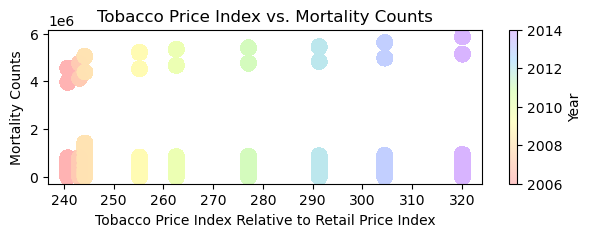

In [53]:
import matplotlib.colors as mcolors

# Convert list of hex colors into a colormap
pastel_cmap = mcolors.LinearSegmentedColormap.from_list("pastel_map", pastel_colors)

plt.figure(figsize=(7,2))
scatter = plt.scatter(
    df['Tobacco Price Index Relative to Retail Price Index'],
    df['Value_y'],
    c=df['Year'],      # numeric now
    cmap=pastel_cmap,  # use custom cmap
    alpha=0.7,
    s=110
)

plt.xlabel('Tobacco Price Index Relative to Retail Price Index')
plt.ylabel('Mortality Counts')
plt.title('Tobacco Price Index vs. Mortality Counts')
plt.colorbar(scatter, label="Year")  # legend for color
plt.show()

-----
## 3. Machine Learning Algorithms
### A) Features Selection 

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# Define feature columns
features = ['Tobacco Price Index Relative to Retail Price Index', '16-24', '25-34', 
            '35-49', '50-59', '60 and Over', 'All Pharmacotherapy Prescriptions']

# Convert target column to numeric (may incur NaNs)
df['Value_y_num'] = pd.to_numeric(df['Value_y'], errors='coerce')

# Drop rows with any NaNs in features or target
df_clean = df.dropna(subset=features + ['Value_y_num'])

# Prepare features and target
X = df_clean[features]
y = df_clean['Value_y_num']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### B) Random Forest Regression 

Question: How effectively can the Random Forest regression model predict mortality counts influenced by smoking-related factors such as tobacco pricing, age-specific smoking prevalence, and pharmacotherapy data?

In [19]:
# Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Mean Square Error: {mse_rf:.4f}")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_rf))

Mean Square Error: 410440258388.0992
Mean Absolute Error: 232584.2389489667


### C) XGBoost Regression
Question: Can the XGBoost regression model provide more accurate predictions of smoking-related mortality counts compared to other models using the same input data, and how well does it capture complex feature interactions?

In [20]:
# XGBoost Model
xgbr = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print(f"Mean Square Error: {mse_xgb:.4f}")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))

Mean Square Error: 410436228429.9520
Mean Absolute Error: 232447.87302518057


### D) Decision Tree RegressionQuestion: Does a decision tree model improve predictions ove XGBoost Regression and Random Forest

In [21]:
# Decision Tree Regression Model
dtr = DecisionTreeRegressor(max_depth=5, random_state=42)
dtr.fit(X_train, y_train)
y_pred_dtr = dtr.predict(X_test)
mse_dtr = mean_squared_error(y_test, y_pred_dtr)
print(f"Mean Square Error: {mse_dtr:.4f}")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_dtr))

Mean Square Error: 410435455467.2398
Mean Absolute Error: 232448.9103030636


### E) Actual vs Predicted Mortality
Question: How closely do model predictions match actual mortality values?

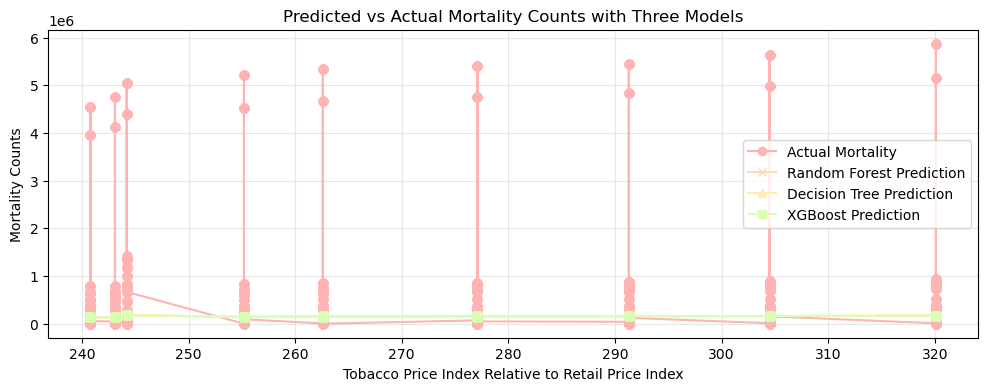

In [28]:
# Visualization of Actual vs Predicted using pastel colors
import numpy as np
plt.figure(figsize=(12,4))

sorted_idx = np.argsort(X_test['Tobacco Price Index Relative to Retail Price Index'])
x_sorted = X_test['Tobacco Price Index Relative to Retail Price Index'].iloc[sorted_idx]
y_test_sorted = y_test.iloc[sorted_idx]
y_pred_rf_sorted = y_pred_rf[sorted_idx]
y_pred_xgb_sorted = y_pred_xgb[sorted_idx]
y_pred_dtr_sorted = y_pred_dtr[sorted_idx]

plt.plot(x_sorted, y_test_sorted, label='Actual Mortality', color='#ffb3b3', marker='o')
plt.plot(x_sorted, y_pred_rf_sorted, label='Random Forest Prediction', color='#ffd9b3', marker='x')
plt.plot(x_sorted, y_pred_dtr_sorted, label='Decision Tree Prediction', color='#ffeeaa', marker='^')
plt.plot(x_sorted, y_pred_xgb_sorted, label='XGBoost Prediction', color='#d9ffb3', marker='s')


plt.xlabel('Tobacco Price Index Relative to Retail Price Index')
plt.ylabel('Mortality Counts')
plt.title('Predicted vs Actual Mortality Counts with Three Models')
plt.legend()
plt.grid(alpha=0.3)
plt.show()